# Assignment 1: Building Neural Networks for Image Classification

## Overview
Welcome back to Assignment 1! In this assignment, you'll dive into the fascinating realm of deep learning by building and training neural networks for image classification and object detection tasks using the PyTorch framework. You'll work with two popular datasets: MNIST for image classification and CIFAR-100 for object detection. Throughout the assignment, you'll also fine-tune your models to achieve optimal results.

## Part 2: Image Classification on CIFAR-100
In the second part, your focus shifts to object classification using the CIFAR-100 dataset. This dataset contains images of various objects grouped into 100 classes. You'll again build both a fully connected neural network and a CNN, but this time, your models will classify objects from the CIFAR-100 dataset. Similar to the previous part, you will fine-tune the models, experimenting with different hyperparameters to achieve optimal results.

# Part 2a: Simple Fully Connected Neural Network - CIFAR 100 Dataset

# Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Specify font family to avoid font warnings on Colab
plt.rcParams['font.family'] = 'DejaVu Sans'

In [2]:
from data import get_dataloaders
import neural_network
import trainer
import visualize

In [ ]:
# Hyperparameters
# TODO: Experiment with different hyperparameters
batch_size = 32
learning_rate = 0.001
epochs = 20

# Load CIFAR-100 dataset and apply transformations

In [4]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
]) # TODO
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])  # TODO

trainloader, testloader = get_dataloaders(
    dataset_name="cifar100", 
    batch_size=batch_size, 
    train_transforms=transform_train, 
    test_transforms=transform_test
)

100%|██████████| 169M/169M [21:03<00:00, 134kB/s]  


# Initialise Fully Connected Neural Network Archictecture

In [5]:
# TODO: Initialize the model, loss function, and optimizer
fc_model = neural_network.FCModel(input_dim=3*32*32, num_classes=100)
criterion = neural_network.ClassificationLoss()  # Use your custom loss function
optimizer = torch.optim.Adam(fc_model.parameters(), lr=learning_rate)

# Training Model

In [6]:
# TODO: Training loop
fc_train_losses, fc_test_losses = trainer.train(
    fc_model, optimizer, criterion, trainloader, testloader, epochs, device
)

Epoch 1/20 - Train Loss: 3.939220033695663
Epoch 1/20 - Test Loss: 3.8172250890884154
Epoch 1/20 - Test Accuracy: 11.73%
Epoch 2/20 - Train Loss: 3.6601912807518295
Epoch 2/20 - Test Loss: 3.8187864017181883
Epoch 2/20 - Test Accuracy: 12.31%
Epoch 3/20 - Train Loss: 3.5533645679305472
Epoch 3/20 - Test Loss: 3.6946899799493176
Epoch 3/20 - Test Accuracy: 14.70%
Epoch 4/20 - Train Loss: 3.4984957383217448
Epoch 4/20 - Test Loss: 3.6666618299941285
Epoch 4/20 - Test Accuracy: 14.88%
Epoch 5/20 - Train Loss: 3.445190402230466
Epoch 5/20 - Test Loss: 3.6583362882510544
Epoch 5/20 - Test Accuracy: 15.51%
Epoch 6/20 - Train Loss: 3.410057886395787
Epoch 6/20 - Test Loss: 3.6579948400917908
Epoch 6/20 - Test Accuracy: 15.18%
Epoch 7/20 - Train Loss: 3.3940132681711774
Epoch 7/20 - Test Loss: 3.746699384226205
Epoch 7/20 - Test Accuracy: 14.87%
Epoch 8/20 - Train Loss: 3.3693989285733252
Epoch 8/20 - Test Loss: 3.7027273993141736
Epoch 8/20 - Test Accuracy: 15.95%
Epoch 9/20 - Train Loss: 3.3

# Visualize Final Results: FCN - CIFAR 100

In [7]:
# Evaluate the models
fc_accuracy = trainer.evaluate_accuracy(fc_model, testloader, device)

# Print test accuracy
print("Fully Connected Model Test Accuracy:", fc_accuracy)

Fully Connected Model Test Accuracy: 14.469999999999999


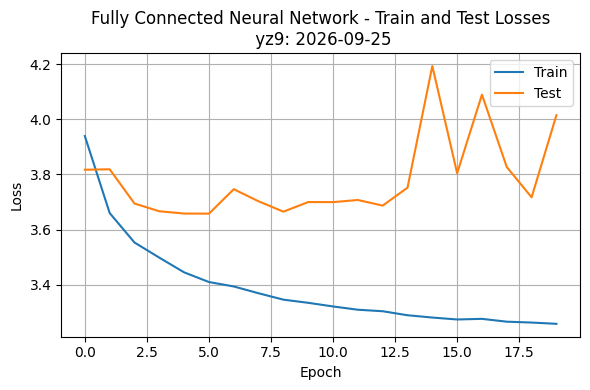

In [8]:
# Plot train and test losses for the fully connected neural network
visualize.visualize_loss(fc_train_losses, fc_test_losses, "Fully Connected Neural Network")

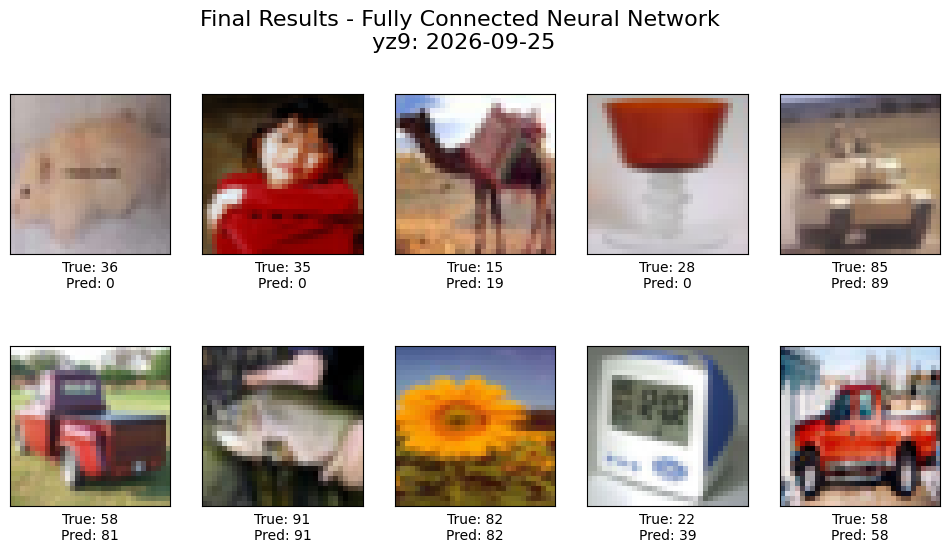

In [9]:
# Visualize the final results
visualize.visualize_images(fc_model, testloader.dataset, device, "Fully Connected Neural Network")

# Part 2b: Convolutional Neural Network - CIFAR 100 Dataset

In [10]:
# TODO: Initialize the CNN model
cnn_model = neural_network.CNNModel(in_channels=3, img_size=32, num_classes=100)
criterion = neural_network.ClassificationLoss()  # Use your custom loss function
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=learning_rate)

In [11]:
# Train the CNN model and record losses
# Define Hyperparameters, if needed
cnn_train_losses, cnn_test_losses = trainer.train(
    cnn_model, cnn_optimizer, criterion, trainloader, testloader, epochs, device
)

Epoch 1/20 - Train Loss: 3.757416196305708
Epoch 1/20 - Test Loss: 3.2656385114017765
Epoch 1/20 - Test Accuracy: 22.81%
Epoch 2/20 - Train Loss: 3.308396419652059
Epoch 2/20 - Test Loss: 3.0343616153485478
Epoch 2/20 - Test Accuracy: 26.78%
Epoch 3/20 - Train Loss: 3.1251873611564904
Epoch 3/20 - Test Loss: 2.8730026837735894
Epoch 3/20 - Test Accuracy: 30.01%
Epoch 4/20 - Train Loss: 2.98835573910294
Epoch 4/20 - Test Loss: 2.7830942256001237
Epoch 4/20 - Test Accuracy: 31.61%
Epoch 5/20 - Train Loss: 2.8973964133174164
Epoch 5/20 - Test Loss: 2.680091946650618
Epoch 5/20 - Test Accuracy: 33.65%
Epoch 6/20 - Train Loss: 2.831543837993937
Epoch 6/20 - Test Loss: 2.6718295511727135
Epoch 6/20 - Test Accuracy: 33.49%
Epoch 7/20 - Train Loss: 2.7735870399310354
Epoch 7/20 - Test Loss: 2.580000706374074
Epoch 7/20 - Test Accuracy: 35.96%
Epoch 8/20 - Train Loss: 2.723649556562066
Epoch 8/20 - Test Loss: 2.5528379583511107
Epoch 8/20 - Test Accuracy: 36.31%
Epoch 9/20 - Train Loss: 2.70055

# Visualize Final Results: CNN - CIFAR 100

In [12]:
# Evaluate the models
cnn_accuracy = trainer.evaluate_accuracy(cnn_model, testloader, device)

# Print test accuracy
print("Convolutional Neural Network Test Accuracy:", cnn_accuracy)

Convolutional Neural Network Test Accuracy: 40.32


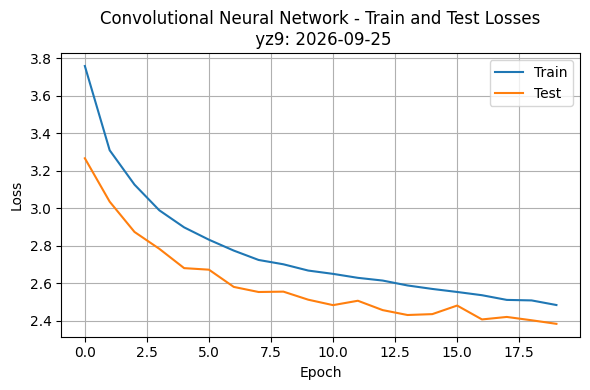

In [13]:
# Plot train and test losses for the Convolutional neural network
visualize.visualize_loss(cnn_train_losses, cnn_test_losses, "Convolutional Neural Network")

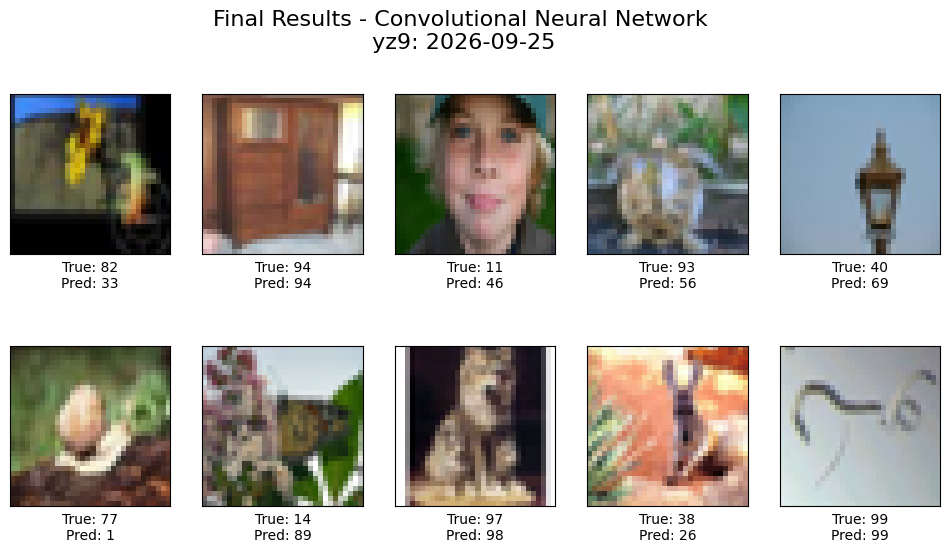

In [14]:
# Visualize the final results
visualize.visualize_images(cnn_model, testloader.dataset, device, "Convolutional Neural Network")